# **Set up**

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

# **Function**

In [116]:
def Gaussian(x, sigma, L_c):
    return np.exp(-(x-L_c)**2/(2*sigma**2))

def Polydisperse_lamellae(q, scale, L_c, p, bkg):
    sigma = p * L_c
    L = np.linspace(max((L_c - 3 * sigma), 0.00001), L_c + 3 * sigma, 100)
   
    I_PD = np.zeros(len(q))
    for i in L:
        x = i * q / 2
        I_PD += Gaussian(i, sigma, L_c) * ((np.sin(x)**2)/(x**2))
       
    return scale * I_PD + bkg

def Polydisperse_lamellae_porod(q, scale, L_c, p, bkg):
    sigma = p * L_c
    L = np.linspace(max((L_c - 3 * sigma), 0.00001), L_c + 3 * sigma, 100)
   
    I_PD = np.zeros(len(q))
    for i in L:
        x = i * q / 2
        I_PD += Gaussian(i, sigma, L_c) * ((np.sin(x)**2)/(x**2))
    I_PD /= max(I_PD)
    I_PD /= x ** 2
    return scale * I_PD + bkg

In [80]:
def K(q, I, z):
    return np.trapezoid(I[:, None] * np.cos(q[:, None] * z[None, :]), q, axis=0)

def IDF(z, K):
    d1 = np.gradient(K, z)
    return np.gradient(d1, z)

def power(x, k, b):
    return b * x ** k

def porod(x, A):
    return A * x ** -4

def smeared_porod(x, A, sigma):
    return A * x ** -4 * np.exp(- x ** 2 * sigma ** 2)

def smeared_porod_backwards(x, sigma):
    return x ** -4 * np.exp(x ** 2 * sigma ** 2)

def Lorenz(x, y, p = 2):
    return x, y * x ** p

def find_porod_A(x, y):
    const = np.mean(y[-10:])
    best_A = 0.5
    y_sub = y - best_A * const

    best_p, best_cov = curve_fit(porod, x, y_sub, bounds=(0, np.inf))
    best_cov_val = np.diag(best_cov)[0]
    
    for A in np.arange(0.5, 1.2, 0.01):
        y_sub = y - A * const
        try:
            p, cov = curve_fit(porod, x, y_sub, bounds=(0, np.inf))
            current_cov = np.diag(cov)[0]
            
            if current_cov < best_cov_val:
                best_cov_val = current_cov
                best_A = A
                best_p = p
        except:
            continue
    
    return best_A * const, best_p

def linear(x, k, b):
    return k * x + b

In [96]:
def analyze_saxs_data(file_path, limits=None, factor=2, porod_const=1.2, sigma=0.0):

    # Default limits if not provided
    if limits is None:
        limits = [0.1, 0.95, 1.6, 2.2]
    
    # Create figure and axes
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    ax1 = axes[0][0]
    ax2 = axes[0][1]
    ax3 = axes[1][0]
    ax4 = axes[1][1]
    
    # Load data
    df = pd.read_csv(file_path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
    q, I = np.array(df['q']), np.array(df['I'])
    
    # Add vertical lines at limits
    for lim in limits:
        ax1.axvline(x=lim, color='black', linestyle='--')
    
    # Plot original data
    ax1.loglog(q, I, color='black', alpha=0.3, label='Original data')
    
    # Porod fitting
    mask_for_porod = (q > limits[-2]) & (q < limits[-1])
    const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
    I_sub = I - const
    
    ax1.loglog(q, I_sub, color='r', alpha=0.3, label='Subtracted data')
    
    # Generate Porod fit
    x_porod = np.linspace(limits[1], 40, 2000)
    Ampl = I_sub[q < limits[1]][-1] * q[q < limits[1]][-1] ** 4
    y_porod = porod_const * smeared_porod(x_porod, Ampl, sigma)
    ax1.plot(x_porod[x_porod < 3], y_porod[x_porod < 3], color='black', label='Porod fit')
    
    # Combine main data with Porod fit
    mask_main = (q > limits[0]) & (q < limits[1])
    res_q = np.concatenate([q[mask_main], x_porod])
    res_I = np.concatenate([I_sub[mask_main], y_porod])
    
    ax1.plot(res_q[res_q < 3], res_I[res_q < 3] / 2, color='black', alpha=0.7)
    ax1.set_xlabel('q (nm$^{-1}$)')
    ax1.set_ylabel('I (a.u.)')
    ax1.legend()
    
    # Lorenz correction
    X_lorenz, Y_lorenz = Lorenz(res_q, res_I, factor)
    ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
    ax2.set_xlim(-0.1, 3)
    ax2.set_xlabel('q (nm$^{-1}$)')
    ax2.set_ylabel('I (a.u.)')
    
    # Correlation function
    dz = 2 * np.pi / max(X_lorenz)
    z = np.linspace(dz, 50, int(50 / dz))
    Corr = K(X_lorenz, Y_lorenz, z)
    Corr /= max(Corr)
    
    # IDF calculation
    idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
    idf /= 2 * max(-idf)
    
    # Plot correlation and IDF
    ax3.plot(z, Corr, color='black', label='Correlation')
    ax3.plot(z, -idf, color='r', alpha=0.4, label='IDF')
    ax3.set_xlim(-1, 50)
    ax3.set_ylim(-0.5, 1)
    ax3.axvline(x=0, color='grey')
    ax3.plot(z, z * 0, color='black', alpha=0.3)
    ax3.set_xlabel('q (nm$^{-1}$)')
    ax3.set_ylabel('K(z) & IDF(z)')
    ax3.legend()
    
    # Detailed correlation analysis
    ax4.plot(z, Corr, color='black')
    ax4.plot(z, z * 0, color='black', alpha=0.3)
    ax4.set_xlim(-1, 30)
    ax4.set_ylim(-0.5, 1)
    
    # Find minima and maxima in specified range
    mask_corr = (z > 4) & (z < 25)
    point_1 = min(Corr[mask_corr])  # minimum in the range
    point_2 = max(Corr[mask_corr])  # maximum in the range
    
    # Mark minimum point
    ax4.scatter(z[Corr == point_1], point_1, zorder=100, color='b', label='Min point')
    ax4.plot(z, point_1 + np.zeros(len(z)), color='grey', alpha=0.5)
    
    # Linear fit for small z
    mask_linear = (z < 2) & (z > 1)
    def linear(x, a, b):
        return a * x + b
    
    popt, cov = curve_fit(linear, z[mask_linear], Corr[mask_linear])
    ax4.plot(z, linear(z, *popt), color='b', alpha=0.2, label='Linear fit')
    
    # Calculate amorphous domain size
    d_amorph = (point_1 - popt[1]) / popt[0]
    ax4.scatter(d_amorph, point_1, color='r', label='d_amorph', zorder=100)
    
    # Mark maximum point
    ax4.scatter(z[Corr == point_2], point_2, zorder=100, color='r', label='Max point')
    lp = z[Corr == point_2][0]
    
    ax4.set_xlabel('z (nm)')
    ax4.set_ylabel('K(z)')
    ax4.legend()
    
    # Calculate results
    d_cr = lp - d_amorph
    ratio = d_cr / lp
    
    # Print results
    print(f'D_amorphous = {d_amorph:.3f}')
    print(f'D_crystalline = {d_cr:.3f}')
    print(f'Long period = {lp:.3f}')
    print(f'Crystalline fraction = {ratio:.3f}')
    
    # Return results
    results = {
        'fig': fig,
        'axes': axes,
        'd_amorphous': d_amorph,
        'd_crystalline': d_cr,
        'long_period': lp,
        'crystalline_fraction': ratio,
        'q': q,
        'I': I,
        'I_subtracted': I_sub,
        'correlation': Corr,
        'idf': idf,
        'z': z,
        'porod_constants': (const, P, Ampl)
    }
    
    return results

In [239]:
def analyze_saxs_data_q_I(q,I , limits=None, factor=2, porod_const=1.2, sigma=0.0, lin1=1, lin2=2):
    """
    Analyze SAXS data including Porod fitting, Lorenz correction, and correlation function analysis.
    
    Parameters:
    -----------
    file_path : str
        Path to the SAXS data file
    limits : list, optional
        List of q limits for different regions [low_q, porod_start, porod_end, high_q]
        Default: [0.1, 0.95, 1.6, 2.2]
    factor : float, optional
        Factor for Lorenz correction (default: 2)
    porod_const : float, optional
        Porod constant multiplier (default: 1.2)
    sigma : float, optional
        Smoothing parameter for smeared Porod (default: 0.0)
    
    Returns:
    --------
    dict : Dictionary containing all results and figure handles
    """
    
    # Default limits if not provided
    if limits is None:
        limits = [0.1, 0.95, 1.6, 2.2]
    
    # Create figure and axes
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    ax1 = axes[0][0]
    ax2 = axes[0][1]
    ax3 = axes[1][0]
    ax4 = axes[1][1]
    
    # Load data
    
    # Add vertical lines at limits
    for lim in limits:
        ax1.axvline(x=lim, color='black', linestyle='--')
    
    # Plot original data
    ax1.loglog(q, I, color='black', alpha=0.3, label='Original data')
    
    # Porod fitting
    mask_for_porod = (q > limits[-2]) & (q < limits[-1])
    const, P = find_porod_A(q[mask_for_porod], I[mask_for_porod])
    I_sub = I - const
    
    ax1.loglog(q, I_sub, color='r', alpha=0.3, label='Subtracted data')
    
    # Generate Porod fit
    x_porod = np.linspace(limits[1], 40, 2000)
    Ampl = I_sub[q < limits[1]][-1] * q[q < limits[1]][-1] ** 4
    y_porod = porod_const * smeared_porod(x_porod, Ampl, sigma)
    ax1.plot(x_porod[x_porod < 3], y_porod[x_porod < 3], color='black', label='Porod fit')
    
    # Combine main data with Porod fit
    mask_main = (q > limits[0]) & (q < limits[1])
    res_q = np.concatenate([q[mask_main], x_porod])
    res_I = np.concatenate([I_sub[mask_main], y_porod])
    
    ax1.plot(res_q[res_q < 3], res_I[res_q < 3] / 2, color='black', alpha=0.7)
    ax1.set_xlabel('q (nm$^{-1}$)')
    ax1.set_ylabel('I (a.u.)')
    ax1.legend()
    
    # Lorenz correction
    X_lorenz, Y_lorenz = Lorenz(res_q, res_I, factor)
    ax2.plot(X_lorenz, Y_lorenz / max(Y_lorenz), color='black')
    ax2.set_xlim(-0.1, 3)
    ax2.set_xlabel('q (nm$^{-1}$)')
    ax2.set_ylabel('I (a.u.)')
    
    # Correlation function
    dz = 2 * np.pi / max(X_lorenz)
    z = np.linspace(dz, 50, int(50 / dz))
    Corr = K(X_lorenz, Y_lorenz, z)
    Corr /= max(Corr)
    
    # IDF calculation
    idf = K(X_lorenz, Y_lorenz * X_lorenz ** 2, z)
    idf /= 2 * max(-idf)
    
    # Plot correlation and IDF
    ax3.plot(z, Corr, color='black', label='Correlation')
    ax3.plot(z, -idf, color='r', alpha=0.4, label='IDF')
    ax3.set_xlim(-1, 50)
    ax3.set_ylim(-0.5, 1)
    ax3.axvline(x=0, color='grey')
    ax3.plot(z, z * 0, color='black', alpha=0.3)
    ax3.set_xlabel('q (nm$^{-1}$)')
    ax3.set_ylabel('K(z) & IDF(z)')
    ax3.legend()
    
    # Detailed correlation analysis
    ax4.plot(z, Corr, color='black')
    ax4.plot(z, z * 0, color='black', alpha=0.3)
    ax4.set_xlim(-1, 30)
    ax4.set_ylim(-0.5, 1)
    
    # Find minima and maxima in specified range
    mask_corr = (z > 4) & (z < 25)
    point_1 = min(Corr[mask_corr])  # minimum in the range
    point_2 = max(Corr[(z>10)&(z<25)])  # maximum in the range
    
    # Mark minimum point
    ax4.scatter(z[Corr == point_1], point_1, zorder=100, color='b', label='Min point')
    ax4.plot(z, point_1 + np.zeros(len(z)), color='grey', alpha=0.5)
    
    # Linear fit for small z
    mask_linear = (z < lin2) & (z > lin1)
    def linear(x, a, b):
        return a * x + b
    
    popt, cov = curve_fit(linear, z[mask_linear], Corr[mask_linear])
    ax4.plot(z, linear(z, *popt), color='b', alpha=0.2, label='Linear fit')
    
    # Calculate amorphous domain size
    d_amorph = (point_1 - popt[1]) / popt[0]
    ax4.scatter(d_amorph, point_1, color='r', label='d_amorph', zorder=100)
    
    # Mark maximum point
    ax4.scatter(z[Corr == point_2], point_2, zorder=100, color='r', label='Max point')
    lp = z[Corr == point_2][0]
    
    ax4.set_xlabel('z (nm)')
    ax4.set_ylabel('K(z)')
    ax4.legend()
    
    # Calculate results
    d_cr = lp - d_amorph
    ratio = d_cr / lp
    
    # Print results
    print(f'D_amorphous = {d_amorph:.3f}')
    print(f'D_crystalline = {d_cr:.3f}')
    print(f'Long period = {lp:.3f}')
    print(f'Crystalline fraction = {ratio:.3f}')
    
    # Return results
    results = {
        'fig': fig,
        'axes': axes,
        'd_amorphous': d_amorph,
        'd_crystalline': d_cr,
        'long_period': lp,
        'crystalline_fraction': ratio,
        'q': q,
        'I': I,
        'I_subtracted': I_sub,
        'correlation': Corr,
        'idf': idf,
        'z': z,
        'porod_constants': (const, P, Ampl)
    }
    
    return results

# **Data**

# first 97 2d

In [263]:
poni =r"\\Synology\Data\2025\SC5711\Linkam_SAXS_13keV_AgBe_1p4m.poni"
ai = pyFAI.load(poni)

In [282]:
# Mask file 
mask = r"\\Synology\Data\2025\SC5711\MASK_capil_linkam_SAXS_5m_Bstmoved_01.edf"
file_mask = mask
img_mask = fabio.open(mask).data

path = r"E:\PE Nikos 2025\BS_moved\PE_Nikos_NG_97_Bstmoved_SAXS_0000.edf"
img = fabio.open(path).data

In [313]:
q1, I1 = ai.integrate1d(img, 2000, mask=img_mask, unit='q_nm^-1')

(1, 1000000.0)

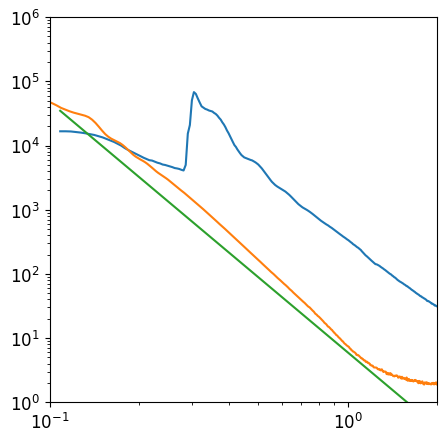

In [314]:

plt.figure(figsize=(5,5))
plt.loglog(q1, I1)

path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_97_RT_SAXS_0005_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
x, y = df['q'], df['I']
plt.loglog(x, y)
plt.loglog(q, 6 * q ** -3.9)

# plt.plot(x, Polydisperse_lamellae_porod(x, 5e7, 71, 0.05, 0))
plt.xlim(0.1, 2)
plt.ylim(1, 1e6)

#### NA 5k

D_amorphous = 3.843
D_crystalline = 9.836
Long period = 13.679
Crystalline fraction = 0.719


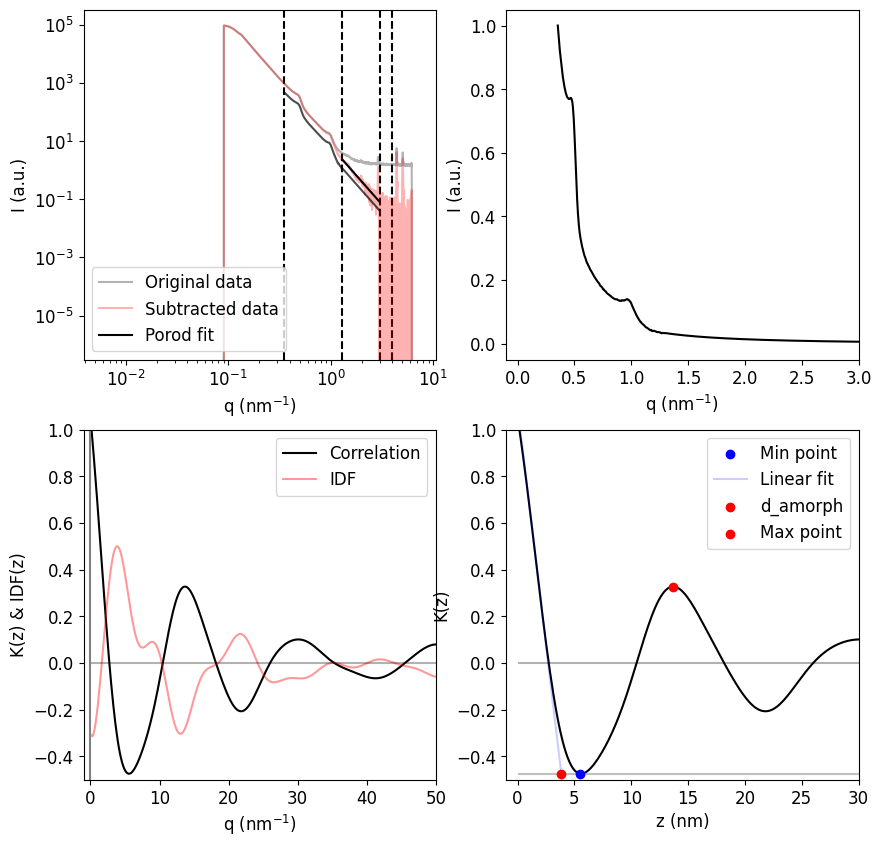

In [90]:
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NA_5k_SAXS_0000_av_c.dat"
results = analyze_saxs_data(path, limits=[0.35, 1.3, 3, 4], factor=2, porod_const=1., sigma=0)


#### NG 73

D_amorphous = 3.718
D_crystalline = 9.175
Long period = 12.893
Crystalline fraction = 0.712


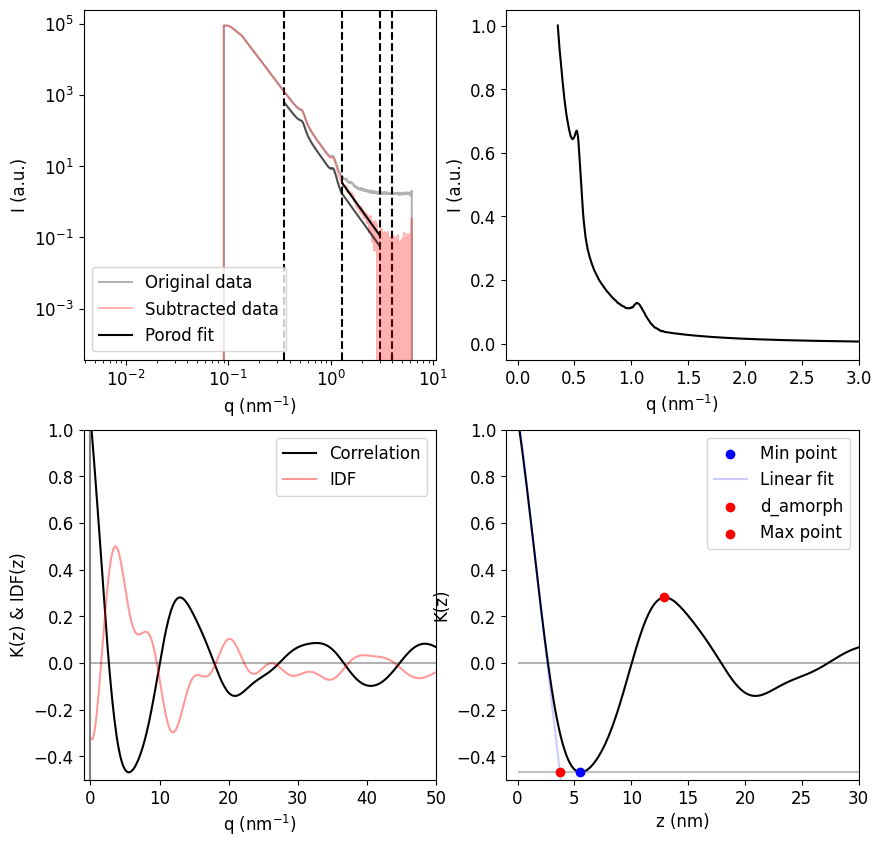

In [91]:
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_73_RT_SAXS_0000_av_c.dat"
results = analyze_saxs_data(path, limits=[0.35, 1.3, 3, 4], factor=2, porod_const=1., sigma=0)


#### NG 82B

(0.03, 2)

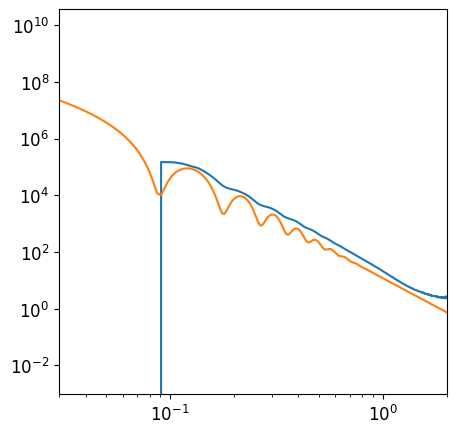

In [130]:
plt.figure(figsize=(5,5))
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_82B_RT_SAXS_0000_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
x, y = df['q'], df['I']
plt.loglog(x, y)

plt.plot(x, Polydisperse_lamellae_porod(x, 5e7, 71, 0.05, 0))
plt.xlim(0.03, 2)

#### NG 86

(1, 1000000.0)

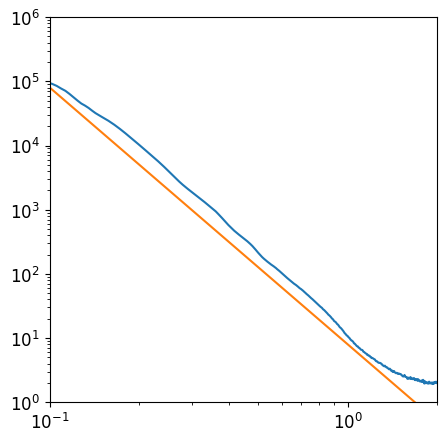

In [143]:
plt.figure(figsize=(5,5))
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_86_RT_SAXS_0000_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
x, y = df['q'], df['I']
plt.loglog(x, y)
plt.loglog(q, 8 * q ** -4)

# plt.plot(x, Polydisperse_lamellae_porod(x, 5e7, 71, 0.05, 0))
plt.xlim(0.1, 2)
plt.ylim(1, 1e6)

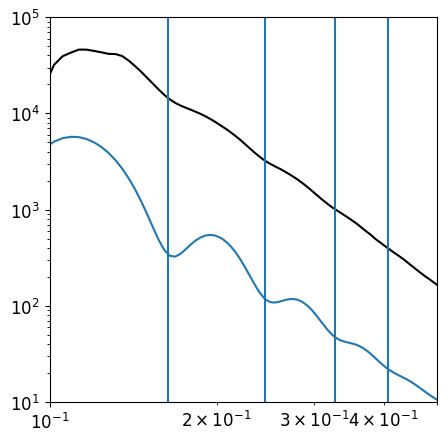

In [196]:
plt.figure(figsize=(5,5))
plt.loglog(x, y - 10 * q ** -4, color='black')

plt.xlim(0.1, 0.5)
plt.ylim(1e1, 1e5)
Lc = 77
plt.plot(x, Polydisperse_lamellae_porod(x, 40e5, Lc, 0.08, 1))
# plt.plot(x, Polydisperse_lamellae_porod(x, 40e5, Lc / 2, 0.08, 1))

for i in range(5):
    plt.axvline(x=2 * pi / Lc * (i + 1))


#### NG 87

(1, 1000000.0)

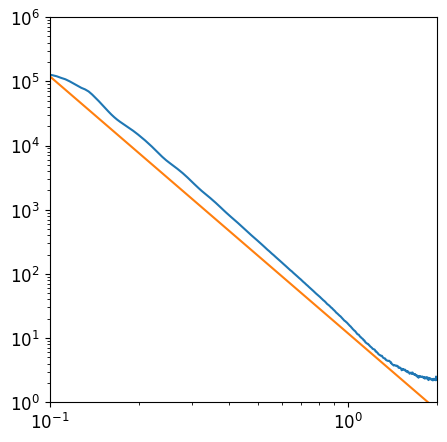

In [297]:
plt.figure(figsize=(5,5))

path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_87_RT_SAXS_0000_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
x, y = df['q'], df['I']
plt.loglog(x, y)
plt.loglog(x, 12 * x ** -4)

# plt.plot(x, Polydisperse_lamellae_porod(x, 5e7, 71, 0.05, 0))
plt.xlim(0.1, 2)
plt.ylim(1, 1e6)

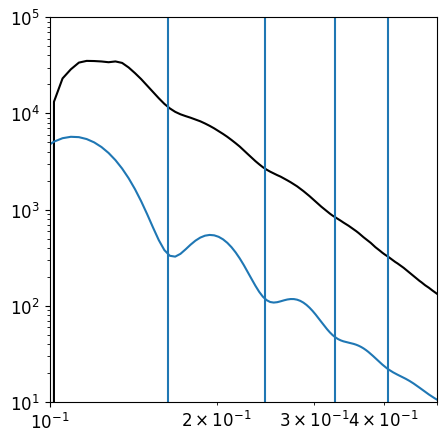

In [304]:
plt.figure(figsize=(5,5))
plt.loglog(x, y - 12 * x ** -4, color='black')

plt.xlim(0.1, 0.5)
plt.ylim(1e1, 1e5)
Lc = 77
plt.plot(x, Polydisperse_lamellae_porod(x, 40e5, Lc, 0.08, 1))
# plt.plot(x, Polydisperse_lamellae_porod(x, 40e5, Lc / 2, 0.08, 1))

for i in range(5):
    plt.axvline(x=2 * pi / Lc * (i + 1))


#### NG 97

(1, 1000000.0)

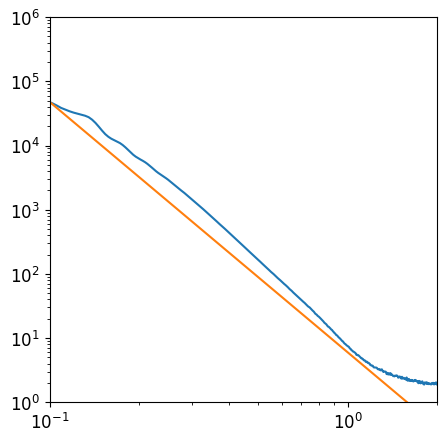

In [315]:
plt.figure(figsize=(5,5))

path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_97_RT_SAXS_0005_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
x, y = df['q'], df['I']
plt.loglog(x, y)
plt.loglog(x, 6 * x ** -3.9)

# plt.plot(x, Polydisperse_lamellae_porod(x, 5e7, 71, 0.05, 0))
plt.xlim(0.1, 2)
plt.ylim(1, 1e6)

In [319]:
2 * pi / 160


0.039269908169872414

In [320]:
2 * pi / 120 


0.05235987755982988

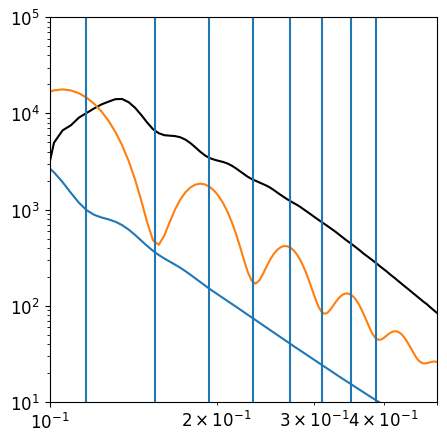

In [325]:
plt.figure(figsize=(5,5))
plt.loglog(x, y - 5.5 * x ** -3.9 , color='black')

plt.xlim(0.1, 0.5)
plt.ylim(1e1, 1e5)
Lc = 162
plt.plot(x, Polydisperse_lamellae_porod(x, 3e7, Lc, 0.1, 1))
plt.plot(x, Polydisperse_lamellae_porod(x, 1e7, Lc / 2, 0.1, 1))

# plt.plot(x, Polydisperse_lamellae_porod(x, 40e5, Lc / 2, 0.08, 1))

for i in range(10):
    plt.axvline(x=2 * pi / Lc * (i + 1))


#### NG

(1, 1000000.0)

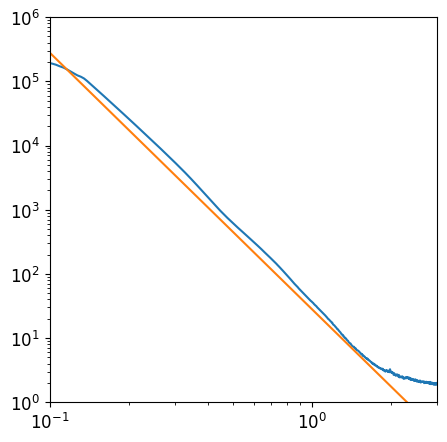

In [232]:
plt.figure(figsize=(5,5))

path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_102_RT_SAXS_0004_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
q, I = df['q'], df['I']
plt.loglog(q, I)

plt.loglog(q, 28 * q ** -4)

plt.xlim(0.1, 3)
plt.ylim(1, 1e6)

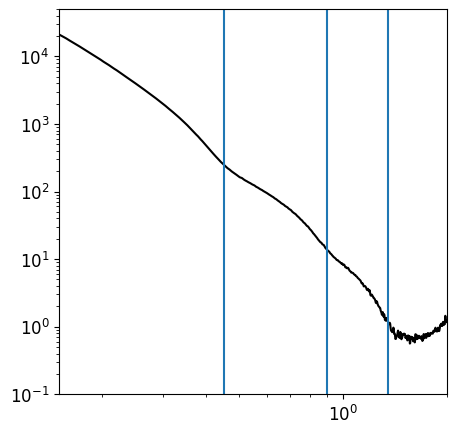

In [233]:
plt.figure(figsize=(5,5))
plt.loglog(q, I - 28 * q ** -4., color='black')
plt.xlim(0.15, 2)
plt.ylim(1e-1, 5e4)

# plt.axvline(x=0.22)
plt.axvline(x=0.45)
plt.axvline(x=0.9)
plt.axvline(x=1.35)

#### NG 86 TFA

D_amorphous = 3.976
D_crystalline = 9.546
Long period = 13.522
Crystalline fraction = 0.706


<Figure size 500x500 with 0 Axes>

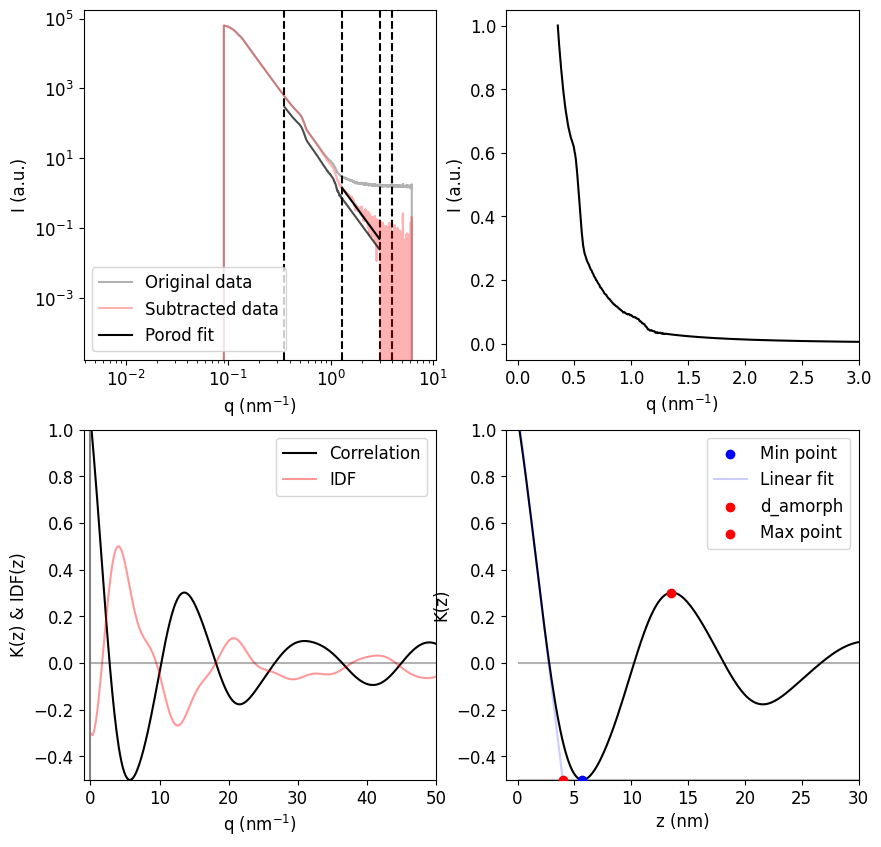

In [236]:
plt.figure(figsize=(5,5))
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_86_TFA_RT_SAXS_0000_av_c.dat"
results = analyze_saxs_data(path, limits=[0.35, 1.3, 3, 4], factor=2, porod_const=1., sigma=0)



#### NG 86 redissolv

D_amorphous = 3.772
D_crystalline = 9.435
Long period = 13.207
Crystalline fraction = 0.714


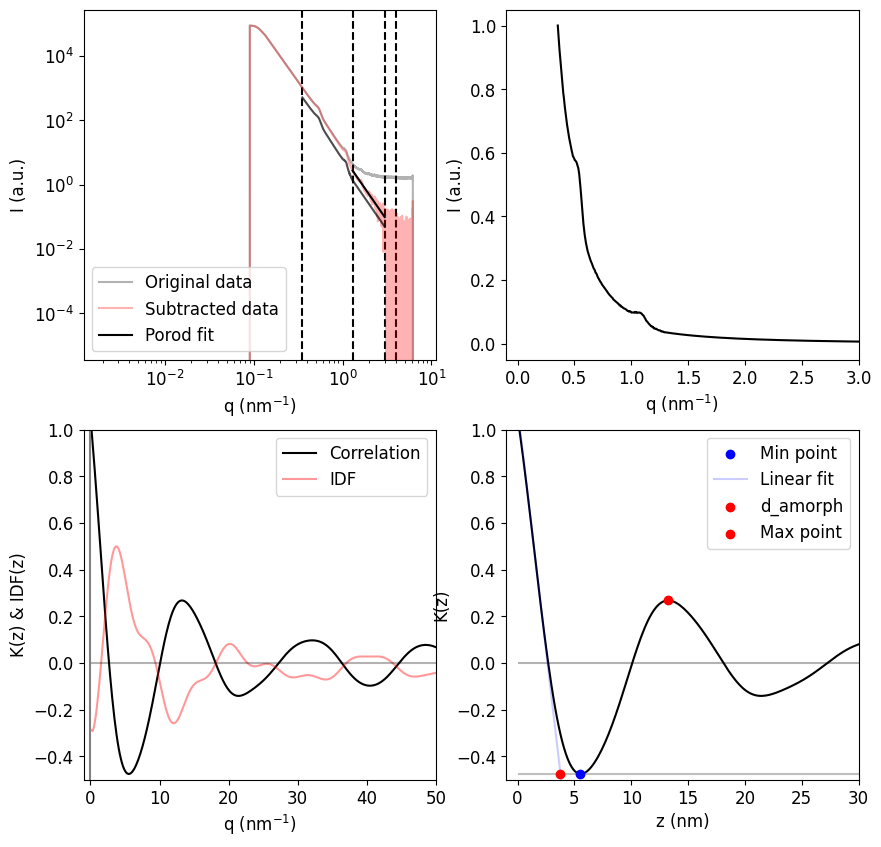

In [242]:
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_86_redissolv_RT'
Exp = BM26_experiment(path)
x, y = Exp.average_1d([0,1,2,3])

res = analyze_saxs_data_q_I(x, y, limits=[0.35, 1.3, 3, 4], factor=2, porod_const=1., sigma=0)

#### NG 97 TFA

D_amorphous = 3.798
D_crystalline = 9.724
Long period = 13.522
Crystalline fraction = 0.719


<Figure size 500x500 with 0 Axes>

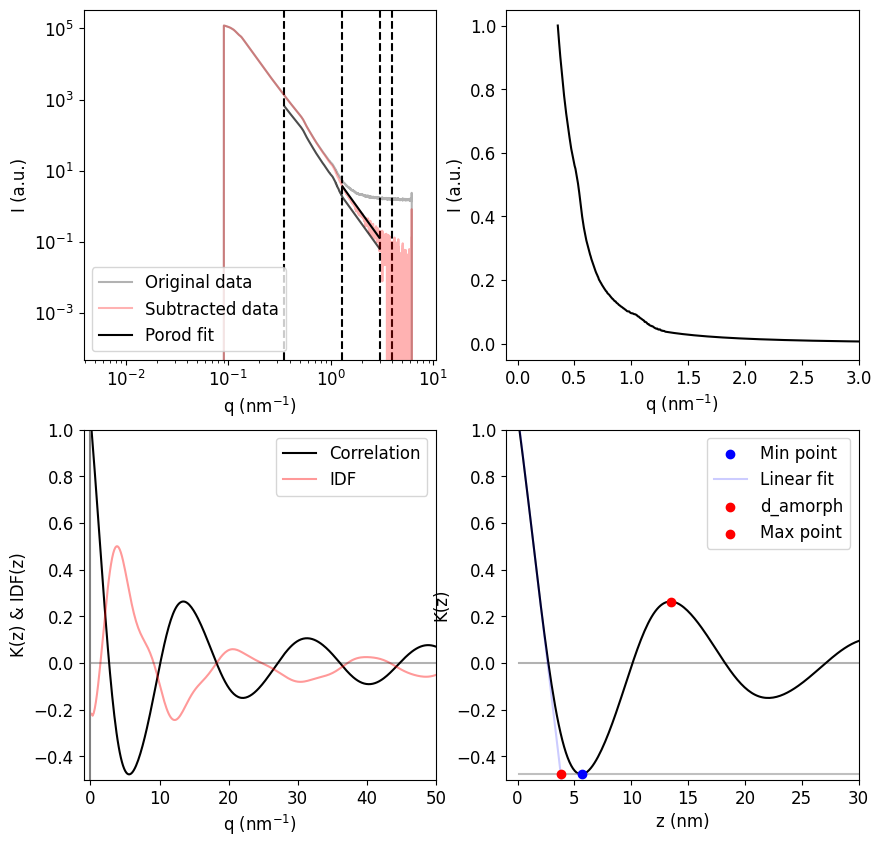

In [246]:
plt.figure(figsize=(5,5))
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_97_TFA_RT_SAXS_0000_av_c.dat"
results = analyze_saxs_data(path, limits=[0.35, 1.3, 3, 4], factor=2, porod_const=1., sigma=0)



#### NG 97 redissolv

D_amorphous = 3.853
D_crystalline = 9.040
Long period = 12.893
Crystalline fraction = 0.701


<Figure size 500x500 with 0 Axes>

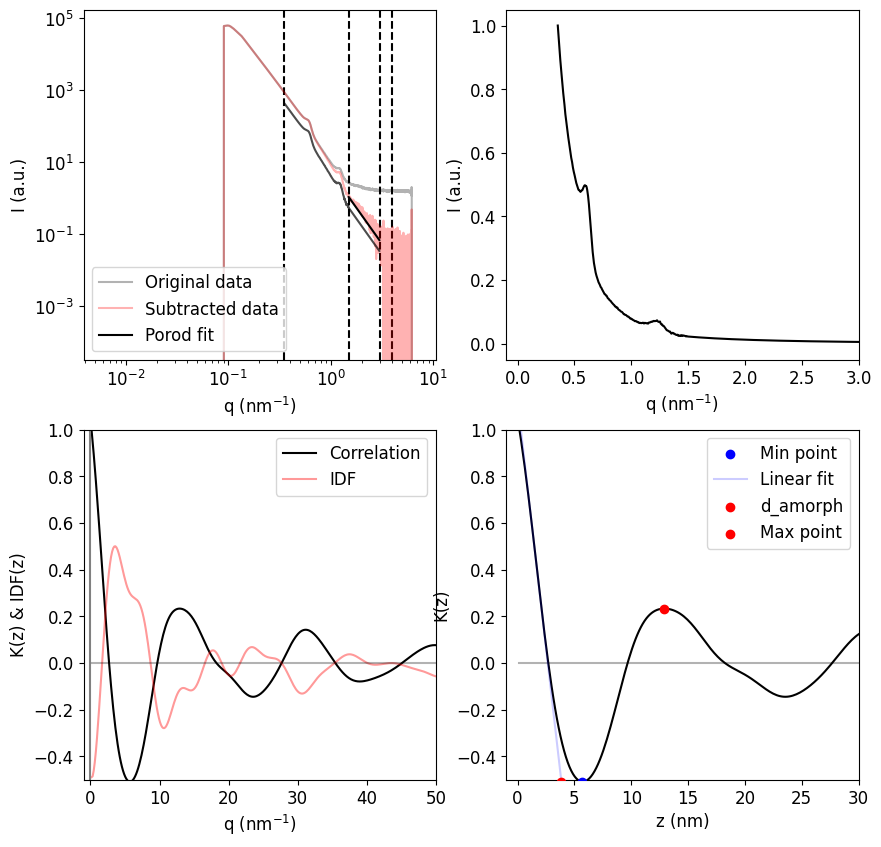

In [245]:
plt.figure(figsize=(5,5))
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_97_redissolv_RT_SAXS_0000_av_c.dat"
results = analyze_saxs_data(path, limits=[0.35, 1.5, 3, 4], factor=2, porod_const=1., sigma=0)



#### NG 96

(1, 1000000.0)

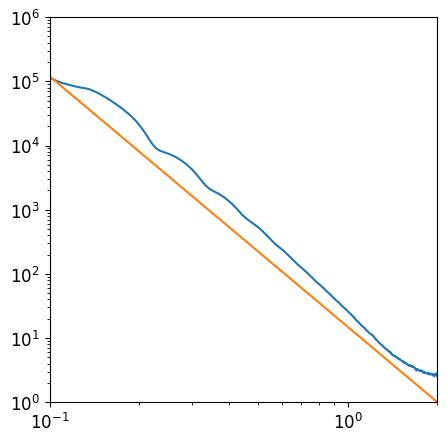

In [249]:
plt.figure(figsize=(5,5))

path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_96_RT_SAXS_0000_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
x, y = df['q'], df['I']
plt.loglog(x, y)
plt.loglog(q, 15 * q ** -3.9)

# plt.plot(x, Polydisperse_lamellae_porod(x, 5e7, 71, 0.05, 0))
plt.xlim(0.1, 2)
plt.ylim(1, 1e6)

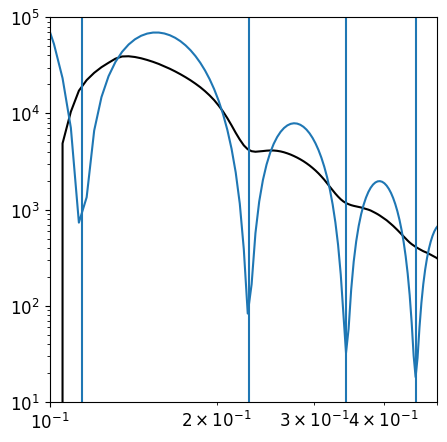

In [259]:
plt.figure(figsize=(5,5))
plt.loglog(x, y -  15 * q ** -3.9 , color='black')

plt.xlim(0.1, 0.5)
plt.ylim(1e1, 1e5)
Lc = 55
plt.plot(x, Polydisperse_lamellae_porod(x, 3e7, Lc, 0.01, 1))
# plt.plot(x, Polydisperse_lamellae_porod(x, 40e5, Lc / 2, 0.08, 1))

for i in range(10):
    plt.axvline(x=2 * pi / Lc * (i + 1))


#### NG 96 TFA

D_amorphous = 3.967
D_crystalline = 9.398
Long period = 13.365
Crystalline fraction = 0.703


<Figure size 500x500 with 0 Axes>

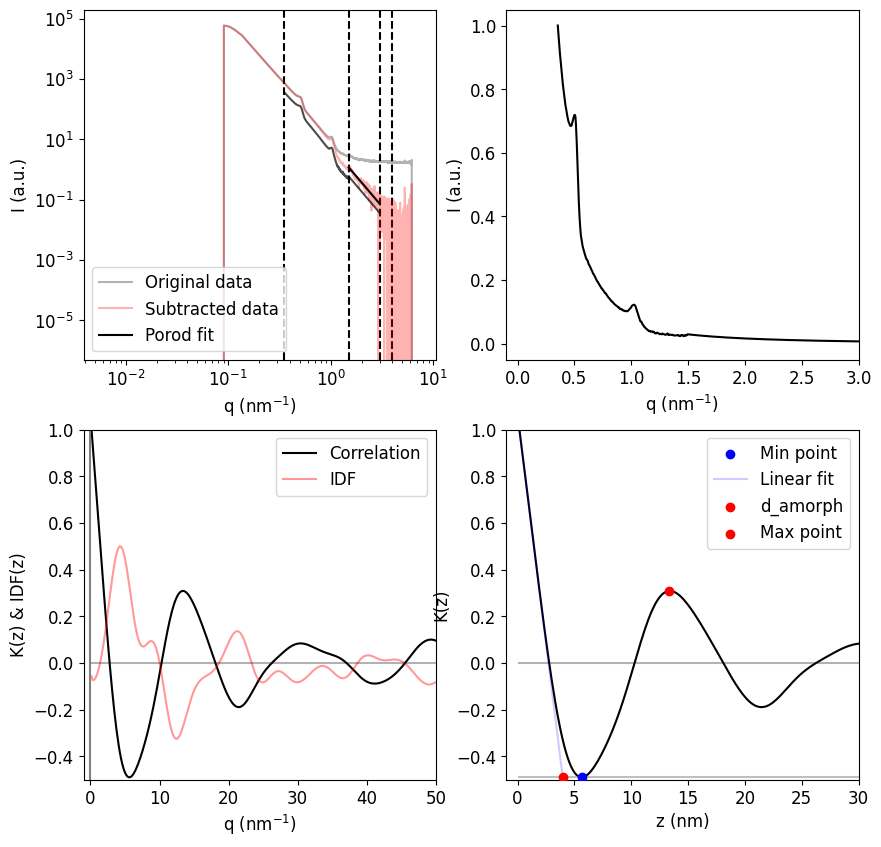

In [261]:
plt.figure(figsize=(5,5))
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_96_TFA_RT_SAXS_0000_av_c.dat"
results = analyze_saxs_data(path, limits=[0.35, 1.5, 3, 4], factor=2, porod_const=1., sigma=0)



#### NG 96 redissolv

D_amorphous = 3.936
D_crystalline = 8.799
Long period = 12.736
Crystalline fraction = 0.691


<Figure size 500x500 with 0 Axes>

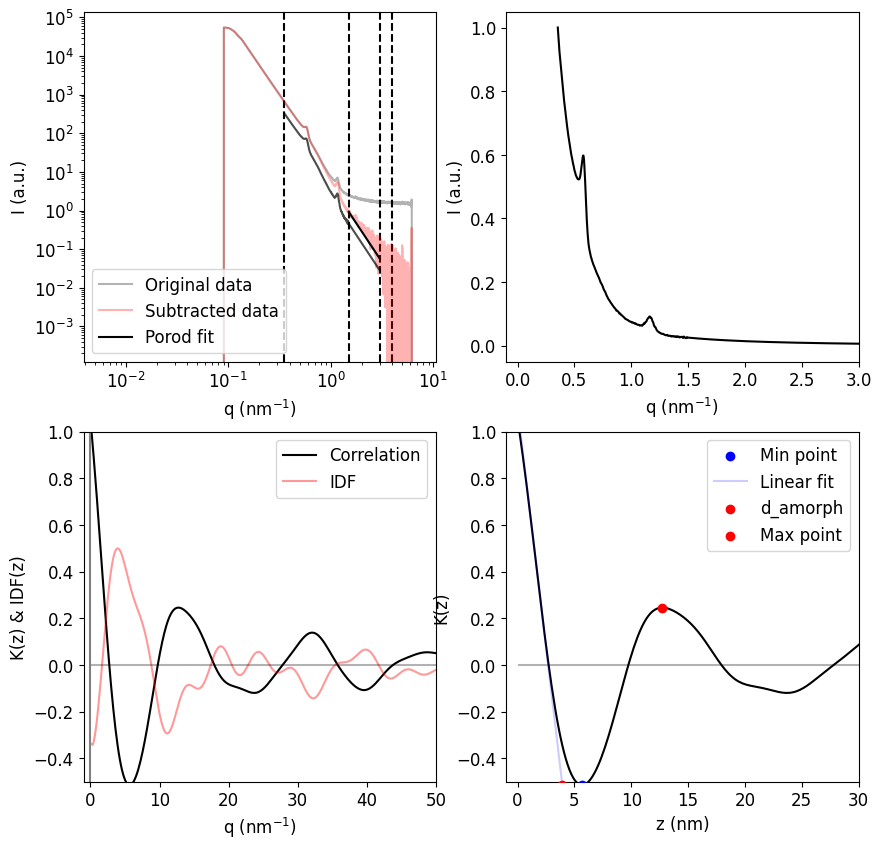

In [262]:
plt.figure(figsize=(5,5))
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_96_redissolv_RT_SAXS_0000_av_c.dat"
results = analyze_saxs_data(path, limits=[0.35, 1.5, 3, 4], factor=2, porod_const=1., sigma=0)



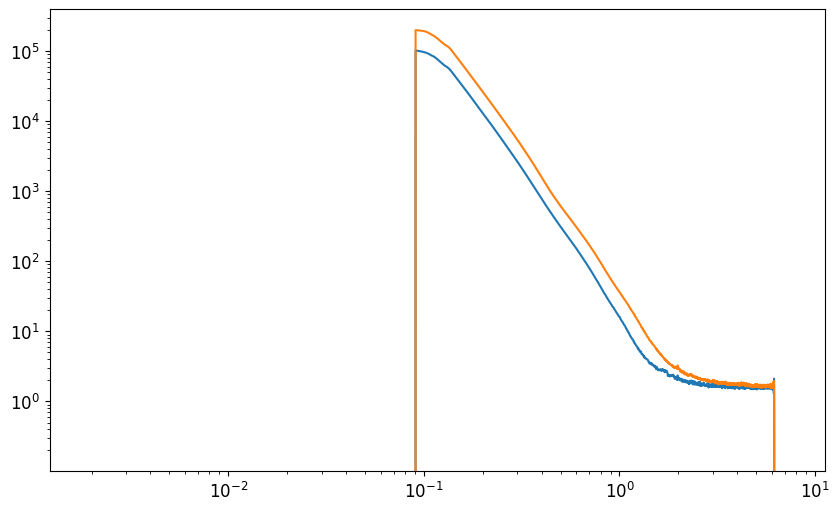

In [43]:
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_101_RT_SAXS_0000_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)

plt.loglog(df['q'], df['I'])


path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_102_RT_SAXS_0004_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)

plt.loglog(df['q'], df['I'])

(1, 1000000.0)

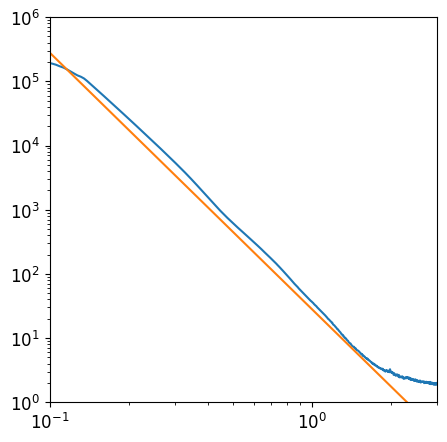

In [45]:
plt.figure(figsize=(5,5))

path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_102_RT_SAXS_0004_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
q, I = df['q'], df['I']
plt.loglog(q, I)

plt.loglog(q, 28 * q ** -4)

plt.xlim(0.1, 3)
plt.ylim(1, 1e6)

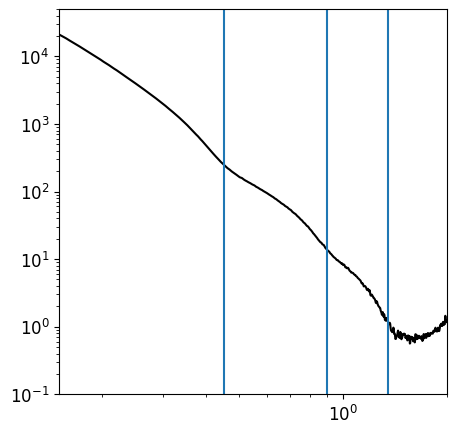

In [39]:
plt.figure(figsize=(5,5))
plt.loglog(q, I - 28 * q ** -4., color='black')
plt.xlim(0.15, 2)
plt.ylim(1e-1, 5e4)

# plt.axvline(x=0.22)
plt.axvline(x=0.45)
plt.axvline(x=0.9)
plt.axvline(x=1.35)

(0.1, 50000.0)

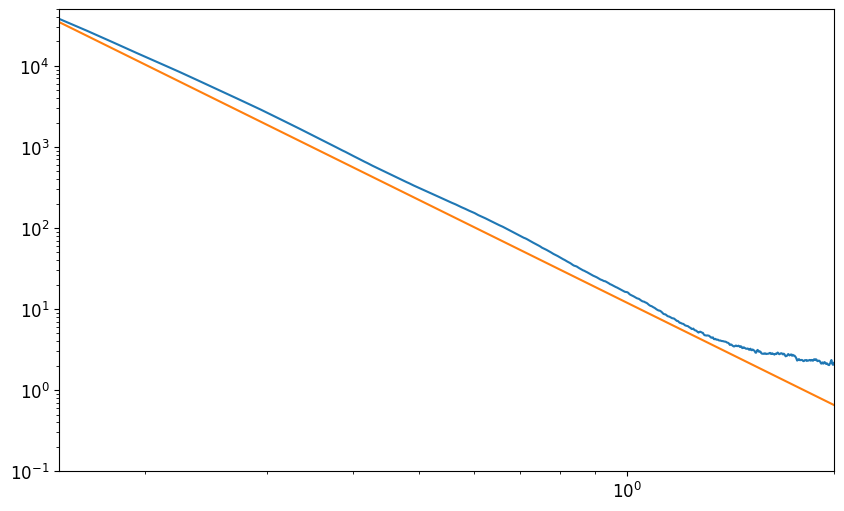

In [72]:
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_101_RT_SAXS_0000_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
q, I = df['q'], df['I']
plt.loglog(q, I)


plt.loglog(q, 12 * q ** -4.2)
plt.xlim(0.15, 2)
plt.ylim(1e-1, 5e4)


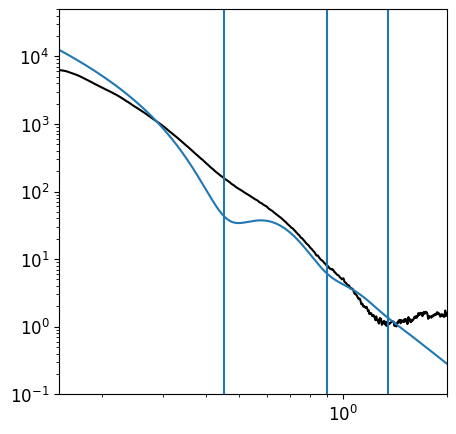

In [78]:
plt.figure(figsize=(5,5))
plt.loglog(q, I - 11 * q ** -4.2, color='black')
plt.xlim(0.15, 2)
plt.ylim(1e-1, 5e4)

# plt.axvline(x=0.22)
plt.axvline(x=0.45)
plt.axvline(x=0.9)
plt.axvline(x=1.35)

Lc = 2 * pi / 0.45
x = np.linspace(1e-2, 2e0, 1000)
y = Polydisperse_lamellae(x, 10, Lc, 0.15, 0)
plt.plot(x, y / x ** 2)

In [55]:
2 * pi / 0.45

13.962634015954636

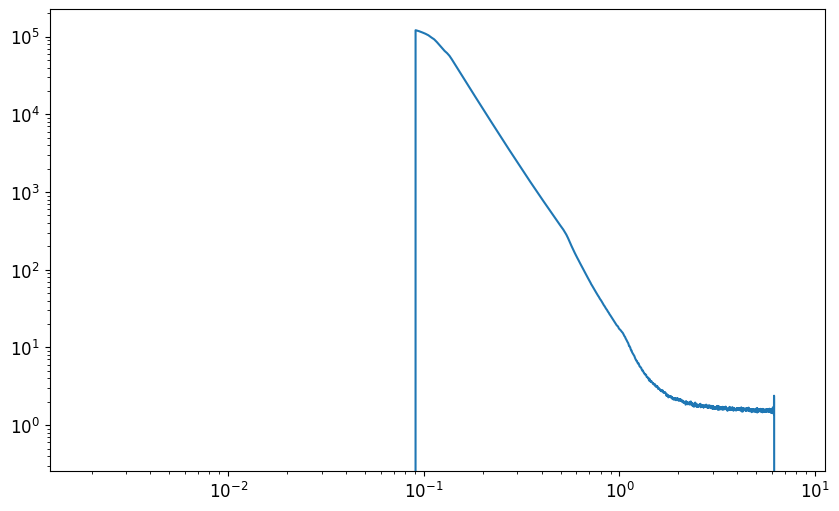

In [79]:
path = r"E:\PE Nikos 2025\RT averaged\dat\PE_samples_NG_97_TFA_RT_SAXS_0000_av_c.dat"
df = pd.read_csv(path, sep='	',  names=['q', 'I', 'err'], skiprows=1)
q, I = df['q'], df['I']
plt.loglog(q, I)
